5.1

In [3]:
import pandas as pd

df = pd.read_csv(
    "grades.csv",
    encoding="utf-8-sig",
    sep=";",
)

print(df.columns)

Index(['Vurderingsfagkode', 'Fagnavn', 'Skolenavn',
       '2024-25.Skriftlig eksamen. Snittkarakter', '2024-25.Skriftlig eksamen',
       '2024-25.Standpunkt. Snittkarakter', '2024-25.Standpunkt'],
      dtype='str')


5.2

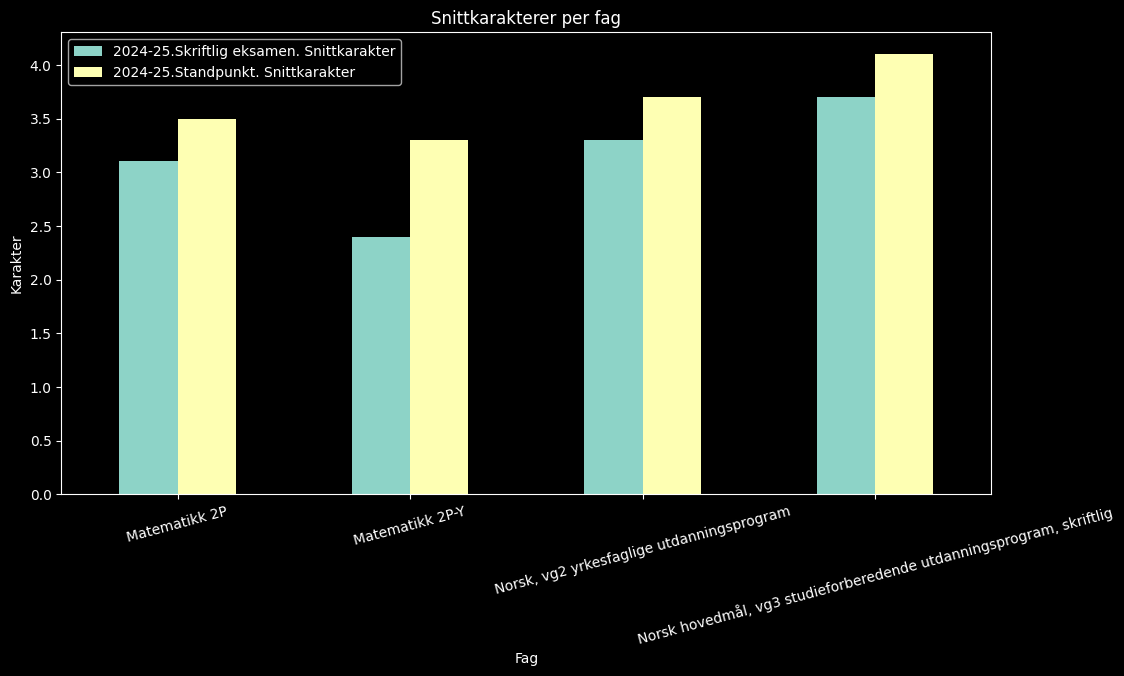

In [40]:
import matplotlib.pyplot as plt

df = df[df["Skolenavn"] == "Alle skoler"]

fag = [
    "Matematikk 2P",
    "Matematikk 2P-Y",
    "Norsk, vg2 yrkesfaglige utdanningsprogram",
    "Norsk hovedmål, vg3 studieforberedende utdanningsprogram, skriftlig"
]

df = df[df["Fagnavn"].isin(fag)]

df["2024-25.Skriftlig eksamen. Snittkarakter"] = (
    df["2024-25.Skriftlig eksamen. Snittkarakter"]
    .astype(str)
    .str.replace(",", ".")
)

df["2024-25.Standpunkt. Snittkarakter"] = (
    df["2024-25.Standpunkt. Snittkarakter"]
    .astype(str)
    .str.replace(",", ".")
)

df["2024-25.Skriftlig eksamen. Snittkarakter"] = pd.to_numeric(
    df["2024-25.Skriftlig eksamen. Snittkarakter"],
    errors="coerce"
)

df["2024-25.Standpunkt. Snittkarakter"] = pd.to_numeric(
    df["2024-25.Standpunkt. Snittkarakter"],
    errors="coerce"
)

df.plot(
    x="Fagnavn",
    y=[
        "2024-25.Skriftlig eksamen. Snittkarakter",
        "2024-25.Standpunkt. Snittkarakter"
    ],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Snittkarakterer per fag")
plt.xlabel("Fag")
plt.ylabel("Karakter")

plt.xticks(rotation=15)

plt.show()


In our dataset, we chose two subjects from the general academic track and two from vocational education. For both tracks, we selected the subjects Norwegian written and Mathematics (2P). We made this choice because we wanted to examine differences in average grades and final (standpunkt) grades, but also to compare differences between general academic and vocational education.

After creating a clustered column chart, we observe that the claim that the average grade for final assessments is higher than the exam average holds true, regardless of educational track and subject. Mathematics, which is a more formula-based subject, generally has a lower average than Norwegian, which is a more essay-based and analytical subject. We also see that students in the general academic track tend to achieve higher averages in these two subjects compared to those in vocational education.

5.3


Research question: Are oral exam grades higher than final course grades in selected school subjects? Differences between years (2022–2025).

Is the gap stable over time?
Is it increasing or decreasing?

In [7]:
import pandas as pd
dataset = pd.read_csv(
    "muntligVSstandpunkt.csv",
    encoding="utf-8-sig",
    sep=";",
)

print(dataset.columns)

Index(['Fagkode', 'Fagnavn', 'Skolenavn',
       '2022-23.Muntlig eksamen Snittkarakter',
       '2022-23.Muntlig eksamen Antall elever',
       '2022-23.Standpunkt Snittkarakter', '2022-23.Standpunkt Antall elever',
       '2023-24.Muntlig eksamen Snittkarakter',
       '2023-24.Muntlig eksamen Antall elever',
       '2023-24.Standpunkt Snittkarakter', '2023-24.Standpunkt Antall elever',
       '2024-25.Muntlig eksamen Snittkarakter',
       '2024-25.Muntlig eksamen Antall elever',
       '2024-25.Standpunkt Snittkarakter', '2024-25.Standpunkt Antall elever'],
      dtype='str')


We selected five subjects that included both a standpunkt grade and a muntlig exam grade. These subjects were chosen because they are mandatory courses required to complete high school. Based on the statement in the exam paper regarding Udir’s analysis, we expect the muntlig exam grades to be higher than the standpunkt grades. We only chose schools in Oslo.

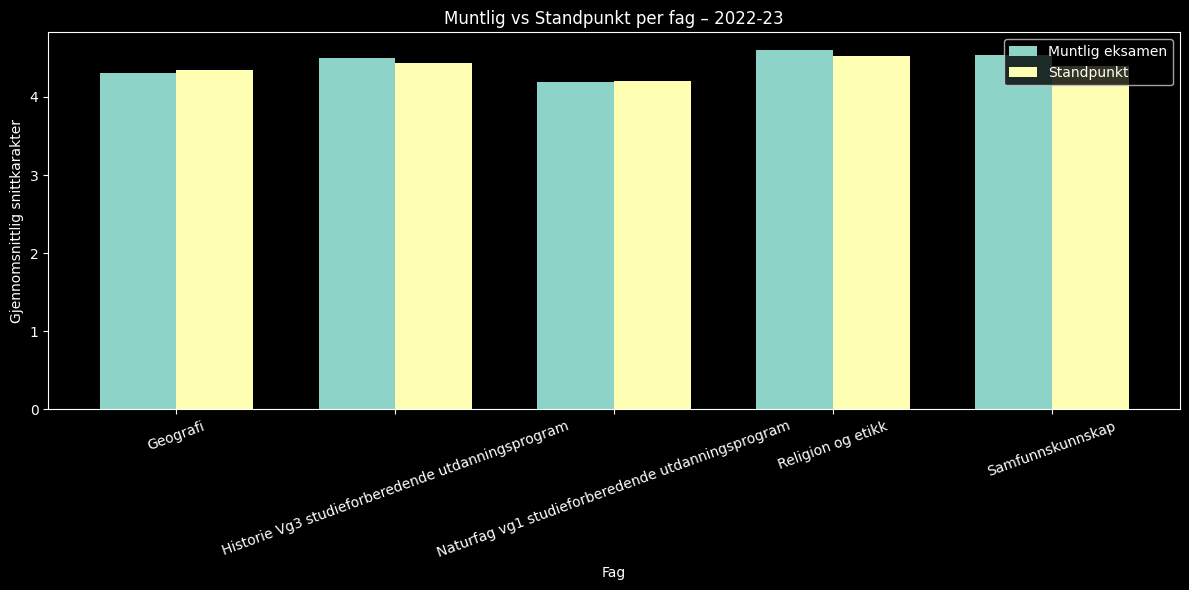

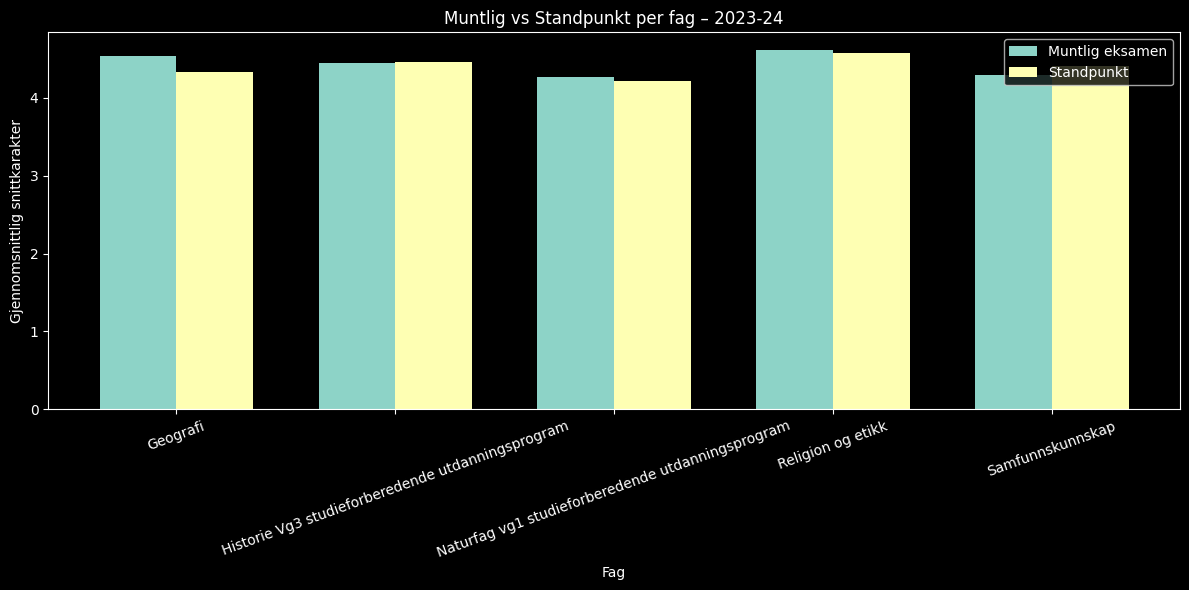

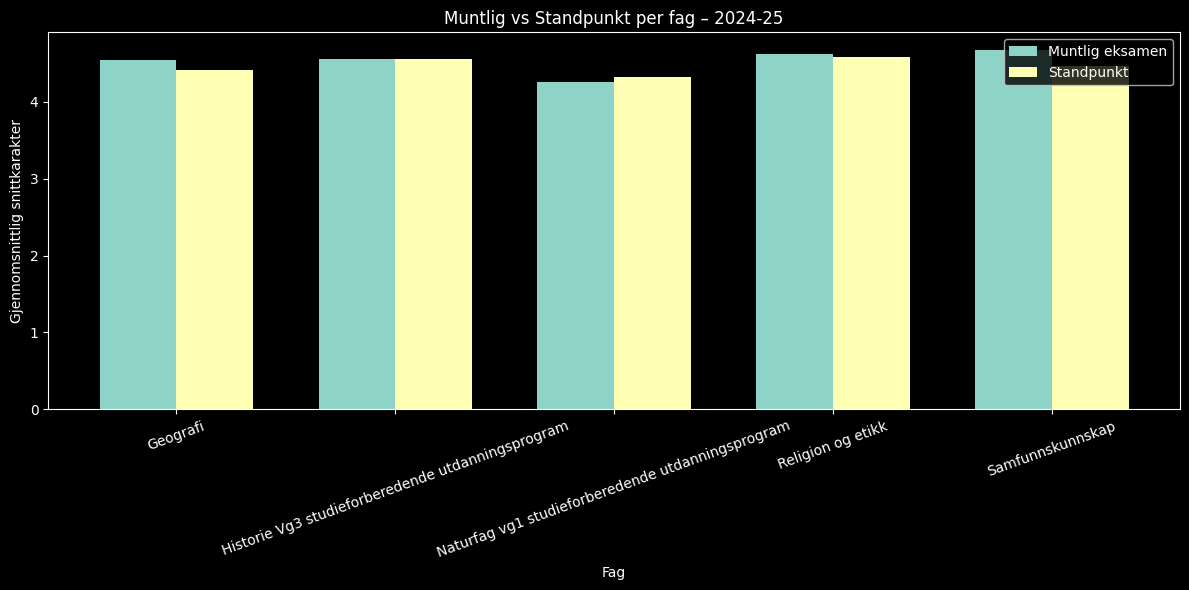

In [8]:
import matplotlib.pyplot as plt
import numpy as np

years = ["2022-23", "2023-24", "2024-25"]

for year in years:

    muntlig_col = f"{year}.Muntlig eksamen Snittkarakter"
    standpunkt_col = f"{year}.Standpunkt Snittkarakter"

    dataset[muntlig_col] = pd.to_numeric(
        dataset[muntlig_col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

    dataset[standpunkt_col] = pd.to_numeric(
        dataset[standpunkt_col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

    temp = (
        dataset.groupby("Fagnavn")[[muntlig_col, standpunkt_col]]
        .mean()
        .reset_index()
    )

    temp = temp.fillna(0)

    x = np.arange(len(temp))
    width = 0.35

    plt.figure(figsize=(12, 6))

    plt.bar(
        x - width / 2,
        temp[muntlig_col],
        width,
        label="Muntlig eksamen"
    )

    plt.bar(
        x + width / 2,
        temp[standpunkt_col],
        width,
        label="Standpunkt"
    )

    plt.xticks(x, temp["Fagnavn"], rotation=20)
    plt.ylabel("Gjennomsnittlig snittkarakter")
    plt.xlabel("Fag")
    plt.title(f"Muntlig vs Standpunkt per fag – {year}")

    plt.legend()
    plt.tight_layout()
    plt.show()

After reviewing the charts and analyzing the results, we concluded that the statement is not entirely correct. As shown in the charts, the difference between the standpunkt grades and the muntlig exam grades is minimal. Furthermore, the article linked in the exam paper was published in 2013, which means the information may no longer be fully accurate.

As mentioned earlier, our data only included schools from Oslo. If we had used a larger dataset from other parts of Norway, the results might have differed slightly. However, since Oslo has the largest student population in Norway, we believe that any difference would likely have been minor.